In [1]:
# Mount Google Drive to save checkpoints
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# **TASK 1 — Data Loading, Merging & Exploratory Data Analysis (EDA)**

# Step 1: Importing libraries

In [ ]:
# Import libraries for data handling
import pandas as pd
import numpy as np

# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for uploading files in Google Colab

# Ignore warning messages for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Step 2 — Upload Dataset Files

In [ ]:
import pandas as pd
import os
import pyarrow as pa
import pyarrow.parquet as pq
import gc

from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# -------------------------------------------------
# Folder path in Google Drive
# -------------------------------------------------
drive_path = '/content/drive/MyDrive/FraudProject/'

# CSV file paths
file_trans_csv = os.path.join(
    drive_path,
    'train_transaction.csv'
)

file_ident_csv = os.path.join(
    drive_path,
    'train_identity.csv'
)

# Parquet output paths
file_trans_pq = os.path.join(
    drive_path,
    'train_transaction.parquet'
)

file_ident_pq = os.path.join(
    drive_path,
    'train_identity.parquet'
)

# -------------------------------------------------
# Function to convert CSV → Parquet
# -------------------------------------------------
def convert_csv_to_parquet(
    csv_file,
    parquet_file,
    chunksize=50000
):

    print(f'Converting {csv_file}...')

    writer = None

    # Read large CSV in chunks
    for chunk in pd.read_csv(
        csv_file,
        chunksize=chunksize,
        low_memory=False
    ):

        # Reduce memory usage
        float_cols = chunk.select_dtypes(
            include=['float64']
        ).columns

        chunk[float_cols] = chunk[
            float_cols
        ].astype('float32')

        # Convert to parquet table
        table = pa.Table.from_pandas(chunk)

        # Create parquet writer
        if writer is None:

            writer = pq.ParquetWriter(
                parquet_file,
                table.schema,
                compression='snappy'
            )

        # Write chunk
        writer.write_table(table)

        # Clear memory
        del chunk, table
        gc.collect()

    # Close writer
    if writer:
        writer.close()

    print(f'Conversion completed: {parquet_file}')

# -------------------------------------------------
# Convert only if parquet doesn't exist
# -------------------------------------------------
if not os.path.exists(file_trans_pq):

    convert_csv_to_parquet(
        file_trans_csv,
        file_trans_pq
    )

if not os.path.exists(file_ident_pq):

    convert_csv_to_parquet(
        file_ident_csv,
        file_ident_pq
    )

# -------------------------------------------------
# Load optimized parquet datasets
# -------------------------------------------------
print('\nLoading Parquet datasets...')

train_transaction = pd.read_parquet(
    file_trans_pq
)

train_identity = pd.read_parquet(
    file_ident_pq
)

# Display shapes
print(
    "\nTransaction Dataset Shape:",
    train_transaction.shape
)

print(
    "Identity Dataset Shape:",
    train_identity.shape
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading Parquet datasets...

Transaction Dataset Shape: (590540, 394)
Identity Dataset Shape: (144233, 41)


# Step 3 — Merge Both Datasets

In [ ]:
# Merge datasets using TransactionID
# Left join keeps all transaction records
df = pd.merge(
    train_transaction,
    train_identity,
    on='TransactionID',
    how='left'
)

# Display merged dataset shape
print("Merged Dataset Shape:", df.shape)

Merged Dataset Shape: (590540, 434)


# Step 4 — Display Dataset Information

In [ ]:
# Display first 10 rows
print("First 10 Rows of Dataset:")
display(df.head(10))

# Display data types
print("\nData Types of First 20 Columns:")
print(df.dtypes.head(20))

# General information about dataset
print("\nDataset Information:")
df.info()

First 10 Rows of Dataset:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Data Types of First 20 Columns:
TransactionID       int64
isFraud             int64
TransactionDT       int64
TransactionAmt    float32
ProductCD          object
card1               int64
card2             float32
card3             float32
card4              object
card5             float32
card6              object
addr1             float32
addr2             float32
dist1             float32
dist2             float32
P_emaildomain      object
R_emaildomain      object
C1                float32
C2                float32
C3                float32
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float32(399), int64(4), object(31)
memory usage: 1.0+ GB


# Step 5 — Analyze Target Column (isFraud)

Fraud Transaction Counts:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud Transaction Percentage:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


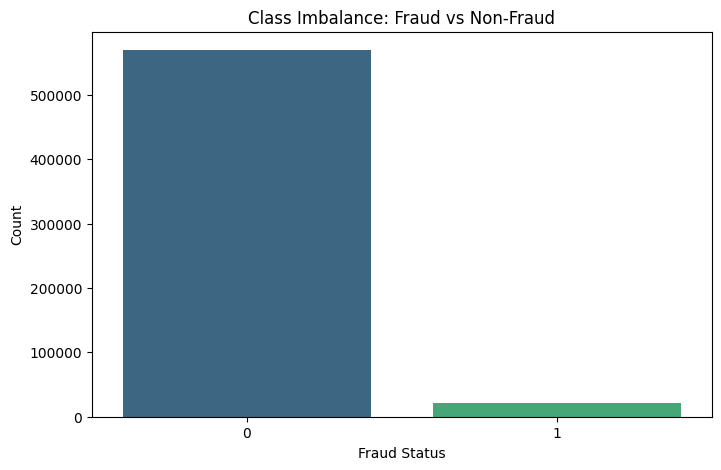

In [ ]:
# Count fraud and non-fraud transactions
fraud_counts = df['isFraud'].value_counts()

# Calculate percentage distribution
fraud_percentage = (
    df['isFraud'].value_counts(normalize=True) * 100
)

# Display results
print("Fraud Transaction Counts:")
print(fraud_counts)

print("\nFraud Transaction Percentage:")
print(fraud_percentage)

# Plot class imbalance
plt.figure(figsize=(8, 5))

sns.countplot(
    x='isFraud',
    data=df,
    palette='viridis'
)

plt.title('Class Imbalance: Fraud vs Non-Fraud')
plt.xlabel('Fraud Status')
plt.ylabel('Count')

plt.show()

# Step 6 — Identify Missing Values

In [ ]:
# Calculate total missing values
missing_values = df.isnull().sum()

# Calculate percentage of missing values
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

# Create missing value report
missing_report = pd.DataFrame({
    'Total Missing Values': missing_values,
    'Missing Percentage': missing_percentage
})

# Sort by highest missing percentage
missing_report = missing_report.sort_values(
    by='Missing Percentage',
    ascending=False
)

# Display top 10 columns with highest missing values
print("Top 10 Columns with Highest Missing Values:")
display(missing_report.head(10))

Top 10 Columns with Highest Missing Values:


,Total Missing Values,Missing Percentage
id_24,585793,99.196159
id_25,585408,99.130965
id_07,585385,99.127070
id_08,585385,99.127070
id_21,585381,99.126393
id_26,585377,99.125715
id_27,585371,99.124699
id_23,585371,99.124699
id_22,585371,99.124699
dist2,552913,93.628374


# Step 7 — Decide Drop vs Imputation Threshold

In [ ]:
# Columns having more than 50% missing values
columns_to_drop = missing_report[
    missing_report['Missing Percentage'] > 50
].index.tolist()

# Display number of columns to drop
print("Number of Columns with >50% Missing Values:")
print(len(columns_to_drop))

# Display first few columns
print("\nSample Columns to Drop:")
print(columns_to_drop[:10])

Number of Columns with >50% Missing Values:
214

Sample Columns to Drop:
['id_24', 'id_25', 'id_07', 'id_08', 'id_21', 'id_26', 'id_27', 'id_23', 'id_22', 'dist2']


# Step 8 — Transaction Amount Distribution

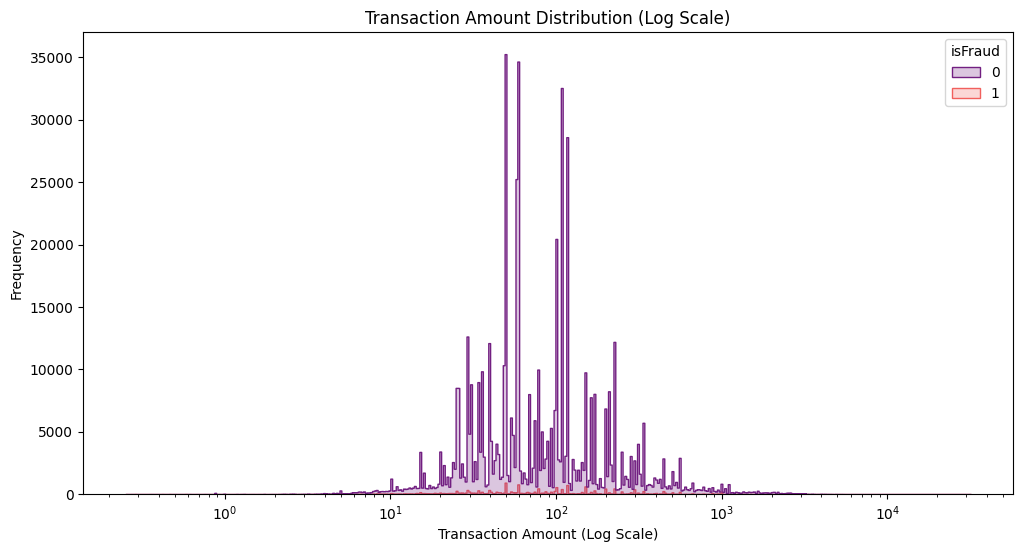

In [ ]:
# Plot distribution of transaction amount
# Log scale is used because transaction values
# are highly skewed

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x='TransactionAmt',
    hue='isFraud',
    palette='magma',
    element='step',
    log_scale=True
)

plt.title(
    'Transaction Amount Distribution (Log Scale)'
)

plt.xlabel('Transaction Amount (Log Scale)')
plt.ylabel('Frequency')

plt.show()

# Step 9 — Correlation Heatmap of Top 20 Numerical Features

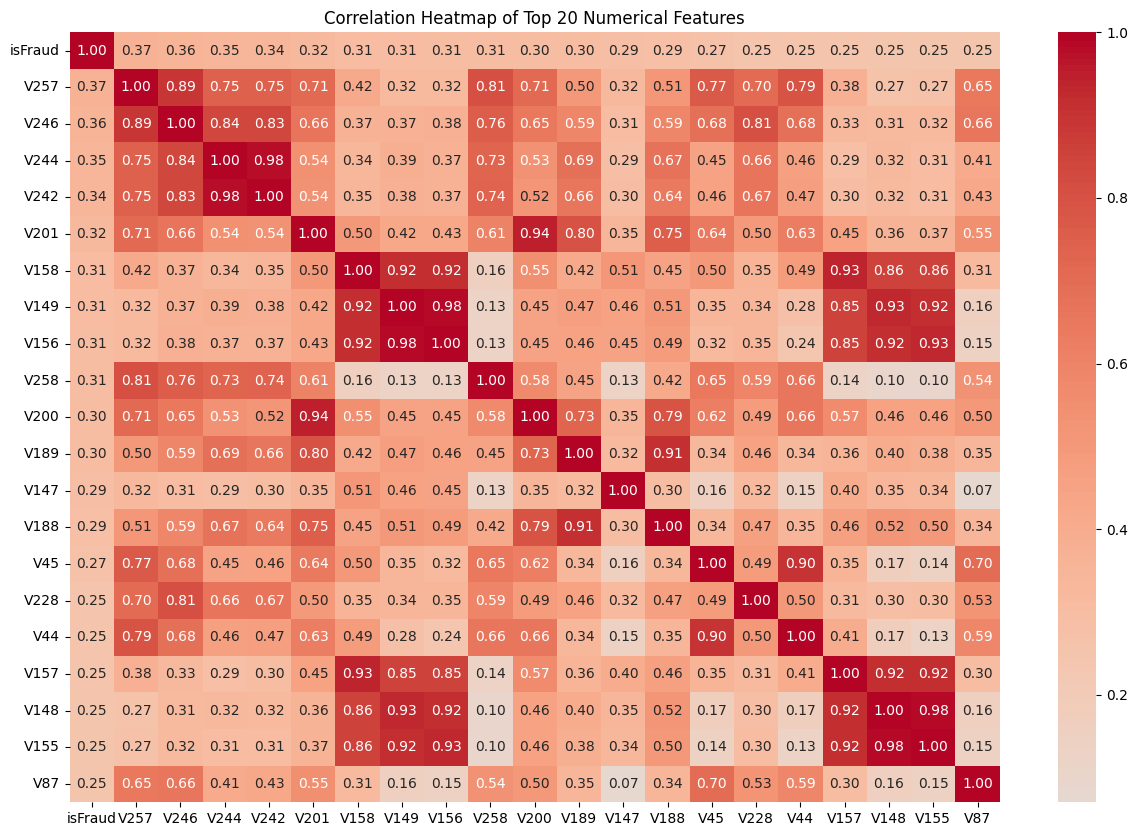

In [ ]:
# Take sample for faster computation
sample_df = df.sample(
    50000,
    random_state=42
)

# Select numerical columns
numerical_columns = sample_df.select_dtypes(
    include=[np.number]
)

# Find top 20 features most correlated with isFraud
top_20_features = (

    numerical_columns.corr()['isFraud']
    .abs()
    .sort_values(ascending=False)
    .head(21)
    .index
)

# Create correlation matrix
correlation_matrix = sample_df[
    top_20_features
].corr()

# Plot heatmap
plt.figure(figsize=(15, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title(
    'Correlation Heatmap of Top 20 Numerical Features'
)

plt.show()

In [ ]:
# END OF TASK 1: SAVE MERGED DATASET TO GOOGLE DRIVE

import os
import pickle

# Create a dedicated directory on your Drive for your capstone project assets
drive_project_dir = "/content/drive/MyDrive/Fraud_Detection_Project/"
os.makedirs(drive_project_dir, exist_ok=True)

task1_path = os.path.join(drive_project_dir, "task1_merged_dataset.pkl")
print("Serializing and saving Task 1 checkpoint to Google Drive...")

# Save all important info from Task 1 needed in later steps
task1_checkpoint = {
    'df': df,
    'missing_report': missing_report if 'missing_report' in globals() else None,
    'missing_values': missing_values if 'missing_values' in globals() else None,
    'missing_percentage': missing_percentage if 'missing_percentage' in globals() else None,
    'columns_to_drop': columns_to_drop if 'columns_to_drop' in globals() else None
}

with open(task1_path, 'wb') as f:
    pickle.dump(task1_checkpoint, f, protocol=4)
print(f"Checkpoint Saved! File path: {task1_path}")


Serializing and saving Task 1 merged data frame to Google Drive...
Checkpoint Saved! File path: /content/drive/MyDrive/Fraud_Detection_Project/task1_merged_dataset.pkl


# Conclusion

- The transaction dataset (590,540 rows, 394 features) was successfully merged with the identity dataset (144,233 rows, 41 features) using TransactionID.

- Exploratory Data Analysis showed a highly imbalanced dataset where fraudulent transactions accounted for only about 3.5% of the total transactions.

- Several columns contained more than 50% missing values and were identified for removal during preprocessing.

- Transaction amount distribution revealed different spending patterns between fraudulent and legitimate transactions.

- Correlation analysis identified important V-series features such as V257, V246, and V244 as strongly related to fraud detection.

- These insights will support preprocessing, feature engineering, and model training in the next stages of the project.

# **TASK 2 — Preprocessing, Imbalance Handling & Feature Engineering**

In [ ]:
import pandas as pd
import os
import pickle

print("Checking Task 1 checkpoint file...")

# -------------------------------------------------
# Path to saved Task 1 dataset
# -------------------------------------------------
task1_path = "/content/drive/MyDrive/Fraud_Detection_Project/task1_merged_dataset.pkl"

# -------------------------------------------------
# Load dataset if file exists
# -------------------------------------------------
if os.path.exists(task1_path):
    print("Loading Task 1 checkpoint into RAM... (Please wait)")
    with open(task1_path, 'rb') as f:
        checkpoint = pickle.load(f)

    # Restore variables
    df = checkpoint.get('df')
    missing_report = checkpoint.get('missing_report')
    missing_values = checkpoint.get('missing_values')
    missing_percentage = checkpoint.get('missing_percentage')
    columns_to_drop = checkpoint.get('columns_to_drop')

    print(f"SUCCESS: Task 1 restored completely into memory!")
    print(f"Active Data Frame Shape: {df.shape}")
else:
    print(f"ERROR: Checkpoint file not found at path: {task1_path}")
    print("Solution: Make sure the file exists in your 'Fraud_Detection_Project' folder on Drive.")


Checking Task 1 checkpoint file...
Loading Task 1 dataset into memory...
Task 1 dataset loaded successfully!
Active DataFrame Shape: (590540, 434)


# Step 1 — Drop Columns with More Than 50% Missing Values

In [ ]:
# Define missing value threshold
threshold = 50

# Identify columns having more than 50% missing values
columns_to_drop = missing_report[
    missing_report['Missing Percentage'] > threshold
].index

# Drop those columns
df_cleaned = df.drop(columns=columns_to_drop)

# Display updated dataset shape
print("Original Dataset Shape:", df.shape)
print("Cleaned Dataset Shape:", df_cleaned.shape)

# Display number of dropped columns
print("\nNumber of Dropped Columns:", len(columns_to_drop))

NameError: name 'missing_report' is not defined

# Step 2 — Handle Missing Values using Median and Mode

In [ ]:
# DROP COLUMNS WITH >50% MISSING VALUES

# Calculate missing percentage directly
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

# Identify columns with >50% missing values
columns_to_drop = missing_percentage[
    missing_percentage > 50
].index

# Drop columns
df_cleaned = df.drop(
    columns=columns_to_drop
)

# Display updated shape
print("Original Dataset Shape:", df.shape)

print("Cleaned Dataset Shape:", df_cleaned.shape)

print(
    "\nNumber of Columns Dropped:",
    len(columns_to_drop)
)

Original Dataset Shape: (590540, 434)
Cleaned Dataset Shape: (590540, 220)

Number of Columns Dropped: 214


In [ ]:
# Separate numerical and categorical columns
numerical_columns = df_cleaned.select_dtypes(
    include=[np.number]
).columns

categorical_columns = df_cleaned.select_dtypes(
    include=['object']
).columns

# --------------------------------------------
# Fill missing numerical values using Median
# --------------------------------------------
df_cleaned[numerical_columns] = (
    df_cleaned[numerical_columns]
    .fillna(df_cleaned[numerical_columns].median())
)

# --------------------------------------------
# Fill missing categorical values using Mode
# --------------------------------------------
for column in categorical_columns:

    df_cleaned[column] = (
        df_cleaned[column]
        .fillna(df_cleaned[column].mode()[0])
    )

print("Missing Value Imputation Completed")

Missing Value Imputation Completed


# Step 3 — Feature Engineering

In [ ]:
# --------------------------------------------
# Feature 1: Amount to Mean Ratio
# --------------------------------------------
df_cleaned['AmtToMeanRatio'] = (
    df_cleaned['TransactionAmt'] /
    df_cleaned['TransactionAmt'].mean()
)

# --------------------------------------------
# Feature 2: Hour of Day
# TransactionDT is in seconds
# --------------------------------------------
df_cleaned['HourOfDay'] = (
    (df_cleaned['TransactionDT'] // 3600) % 24
)

# --------------------------------------------
# Feature 3: Device Risk Flag
# Mobile devices are considered higher risk
# --------------------------------------------
if 'DeviceType' in df_cleaned.columns:

    df_cleaned['DeviceRisk'] = (
        df_cleaned['DeviceType']
        .apply(lambda x: 1 if x == 'mobile' else 0)
    )

else:

    # Fallback if DeviceType is unavailable
    df_cleaned['DeviceRisk'] = 0

# Display engineered features
display(
    df_cleaned[
        ['AmtToMeanRatio', 'HourOfDay', 'DeviceRisk']
    ].head()
)

,AmtToMeanRatio,HourOfDay,DeviceRisk
0,0.507305,0,0
1,0.214772,0,0
2,0.436949,0,0
3,0.370296,0,0
4,0.370296,0,0


# Step 4 — Label Encoding for Categorical Features

In [ ]:
# Initialize Label Encoder
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# Encode categorical columns
for column in categorical_columns:

    df_cleaned[column] = label_encoder.fit_transform(
        df_cleaned[column].astype(str)
    )

print("Categorical Feature Encoding Completed")

NameError: name 'categorical_columns' is not defined

# Step 5 — Train-Test Split and Feature Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# Define feature matrix and target variable
X = df_cleaned.drop(
    ['isFraud', 'TransactionID'],
    axis=1
)

y = df_cleaned['isFraud']

# --------------------------------------------
# Stratified 80/20 Train-Test Split
# --------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

# --------------------------------------------
# Apply RobustScaler
# --------------------------------------------
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature Scaling Completed")

Training Set Shape: (472432, 221)
Testing Set Shape: (118108, 221)

Feature Scaling Completed


# Step 6 — Apply SMOTE on Training Set

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Display class distribution before balancing
print("--- Class Distribution Before SMOTE ---")
print(Counter(y_train))

# Initialize SMOTE engine
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# 4. Display class distribution
print("\n--- Class Distribution After SMOTE ---")
print(Counter(y_train_resampled))
print("\nSMOTE variables are now successfully stored in memory!")

--- Class Distribution Before SMOTE ---


NameError: name 'y_train' is not defined

In [ ]:
# END OF TASK 2: SAVE RESAMPLED & SCALED ML SUBSETS
import pickle
import os

task2_path = "/content/drive/MyDrive/Fraud_Detection_Project/task2_processed_arrays.pkl"
print("Bundling and caching processed matrices and arrays...")

# Put train and validation datasets into an indexable dictionary block
task2_checkpoint = {
    'X_train_resampled': X_train_resampled,
    'y_train_resampled': y_train_resampled,
    'X_test_scaled': X_test_scaled,
    'y_test': y_test,
    'feature_names': list(X_train.columns) if 'X_train' in globals() else None,
    'scaler': scaler if 'scaler' in globals() else None,
    'X_test_index': X_test.index if 'X_test' in globals() else None,
    'df_cleaned': df_cleaned if 'df_cleaned' in globals() else None,
    'df': df if 'df' in globals() else None
}

with open(task2_path, 'wb') as f:
    pickle.dump(task2_checkpoint, f, protocol=4) # Protocol 4 handles massive numeric matrices rapidly

print(f"Checkpoint Saved! File path: {task2_path}")


# Conclusion

The dataset was successfully preprocessed by removing columns with excessive missing values and imputing the remaining missing data using median and mode strategies.

Several engineered features such as transaction amount ratio, transaction hour, and device risk were created to improve fraud detection capability.

Categorical variables were transformed using Label Encoding, and RobustScaler was applied to reduce the impact of outliers. Finally, SMOTE was used only on the training dataset to balance the fraud classes and improve model learning performance.

# **TASK 3 — Model Training, Comparison & Threshold Optimization**

In [2]:
import pickle

with open("/content/drive/MyDrive/Fraud_Detection_Project/task2_processed_arrays.pkl", 'rb') as f:
    checkpoint = pickle.load(f)

X_train_resampled = checkpoint.get('X_train_resampled')
y_train_resampled = checkpoint.get('y_train_resampled')
X_test_scaled = checkpoint.get('X_test_scaled')
y_test = checkpoint.get('y_test')
feature_names = checkpoint.get('feature_names')
scaler = checkpoint.get('scaler')
X_test_index = checkpoint.get('X_test_index')
df_cleaned = checkpoint.get('df_cleaned')
df = checkpoint.get('df')

# Mock X_test if we only saved index, to avoid undefined variable errors later
if X_test_index is not None:
    import pandas as pd
    X_test = pd.DataFrame(index=X_test_index)

print("Task 2 subsets restored successfully! Ready to feed straight into model training loops.")


Task 2 subsets restored successfully! Ready to feed straight into model training loops.


# Step 1 — Import Libraries and Initialize Models

In [3]:
# Import Machine Learning models
import lightgbm as lgb
import xgboost as xgb

from sklearn.ensemble import IsolationForest

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    auc,
    confusion_matrix,
    roc_curve,
    classification_report
)

# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize Models

models = {

    "LightGBM": lgb.LGBMClassifier(
        n_estimators=100,
        random_state=42
    ),

    "XGBoost": xgb.XGBClassifier(
        n_estimators=100,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ),

    "IsolationForest": IsolationForest(
        n_estimators=100,
        contamination=0.035,
        random_state=42
    )
}

# Dictionary to store results
results = {}

# Step 2 — Train Models and Evaluate Performance

In [5]:
import numpy as np
# Loop through all models
for model_name, model in models.items():

    print(f"\nTraining {model_name}...")

    # ----------------------------------------
    # Isolation Forest (Unsupervised Model)
    # ----------------------------------------
    if model_name == "IsolationForest":

        # Train model
        model.fit(X_train_resampled)

        # Predict anomalies
        predictions = model.predict(X_test_scaled)

        # Convert predictions:
        # -1 = Fraud
        #  1 = Legitimate
        y_pred = np.where(predictions == -1, 1, 0)

        # Generate anomaly scores
        y_probs = model.decision_function(
            X_test_scaled
        )

    # ----------------------------------------
    # Supervised Models
    # ----------------------------------------
    else:

        # Train model
        model.fit(
            X_train_resampled,
            y_train_resampled
        )

        # Predictions
        y_pred = model.predict(
            X_test_scaled
        )

        # Prediction probabilities
        y_probs = model.predict_proba(
            X_test_scaled
        )[:, 1]

    # ----------------------------------------
    # Precision-Recall values
    # ----------------------------------------
    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_test,
            y_probs
        )
    )

    # ----------------------------------------
    # Store evaluation metrics
    # ----------------------------------------
    results[model_name] = {

        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "Precision": precision_score(
            y_test,
            y_pred
        ),

        "Recall": recall_score(
            y_test,
            y_pred
        ),

        "F1_Score": f1_score(
            y_test,
            y_pred
        ),

        "ROC_AUC": roc_auc_score(
            y_test,
            y_probs
        ),

        "PR_AUC": auc(
            recall_curve,
            precision_curve
        ),

        "Predictions": y_pred,

        "Probabilities": y_probs
    }

    # ----------------------------------------
    # Display Classification Report
    # ----------------------------------------
    print(f"\nClassification Report: {model_name}")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )


Training LightGBM...
[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.927138 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 52838
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 217
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Classification Report: LightGBM
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.72      0.43      0.54      4133

    accuracy                           0.97    118108
   macro avg       0.85      0.71      0.76    118108
weighted avg       0.97      0.97      0.97    118108


Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:15:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report: XGBoost
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.77      0.49      0.60      4133

    accuracy                           0.98    118108
   macro avg       0.88      0.74      0.79    118108
weighted avg       0.97      0.98      0.97    118108


Training IsolationForest...

Classification Report: IsolationForest
              precision    recall  f1-score   support

           0       0.97      0.99      0.98    113975
           1       0.13      0.05      0.08      4133

    accuracy                           0.95    118108
   macro avg       0.55      0.52      0.53    118108
weighted avg       0.94      0.95      0.95    118108



# Step 3 — Display Model Comparison Table

In [6]:
# Convert results dictionary into DataFrame
comparison_df = pd.DataFrame(results).T

# Remove prediction columns for cleaner display
comparison_df = comparison_df.drop(
    columns=['Predictions', 'Probabilities']
)

# Display comparison table
print("Model Performance Comparison:")

display(comparison_df)

# Save comparison table as image if needed
comparison_df.to_csv("model_comparison.parquet")

Model Performance Comparison:


,Accuracy,Precision,Recall,F1_Score,ROC_AUC,PR_AUC
LightGBM,0.974185,0.722131,0.426325,0.536133,0.893407,0.542367
XGBoost,0.977021,0.772152,0.487055,0.597329,0.912401,0.617294
IsolationForest,0.954516,0.133649,0.054682,0.07761,0.350427,0.025749


# Step 4 — Confusion Matrix Visualization

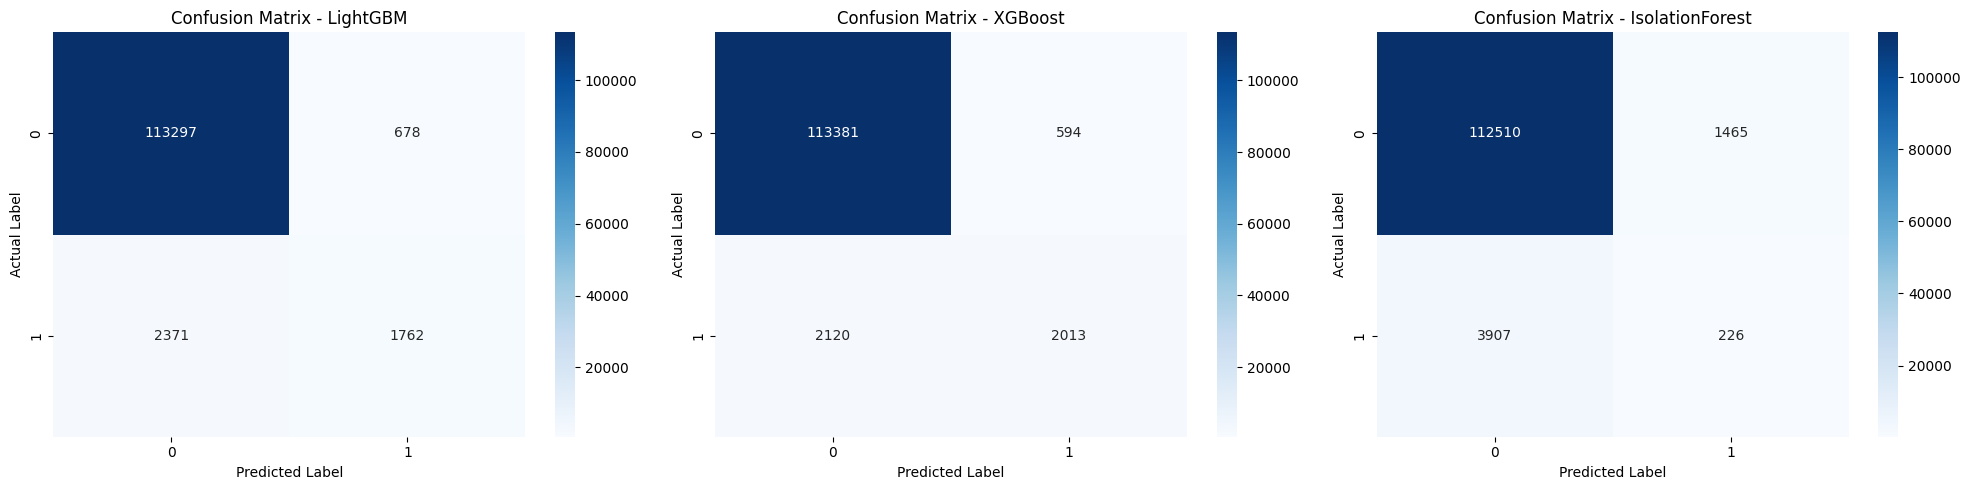

In [7]:
# Create subplot layout
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5)
)

# Plot confusion matrix for each model
for i, (model_name, result) in enumerate(results.items()):

    cm = confusion_matrix(
        y_test,
        result['Predictions']
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i]
    )

    axes[i].set_title(
        f'Confusion Matrix - {model_name}'
    )

    axes[i].set_xlabel('Predicted Label')

    axes[i].set_ylabel('Actual Label')

plt.tight_layout()

plt.show()

# Step 5 — ROC Curve and Precision-Recall Curve

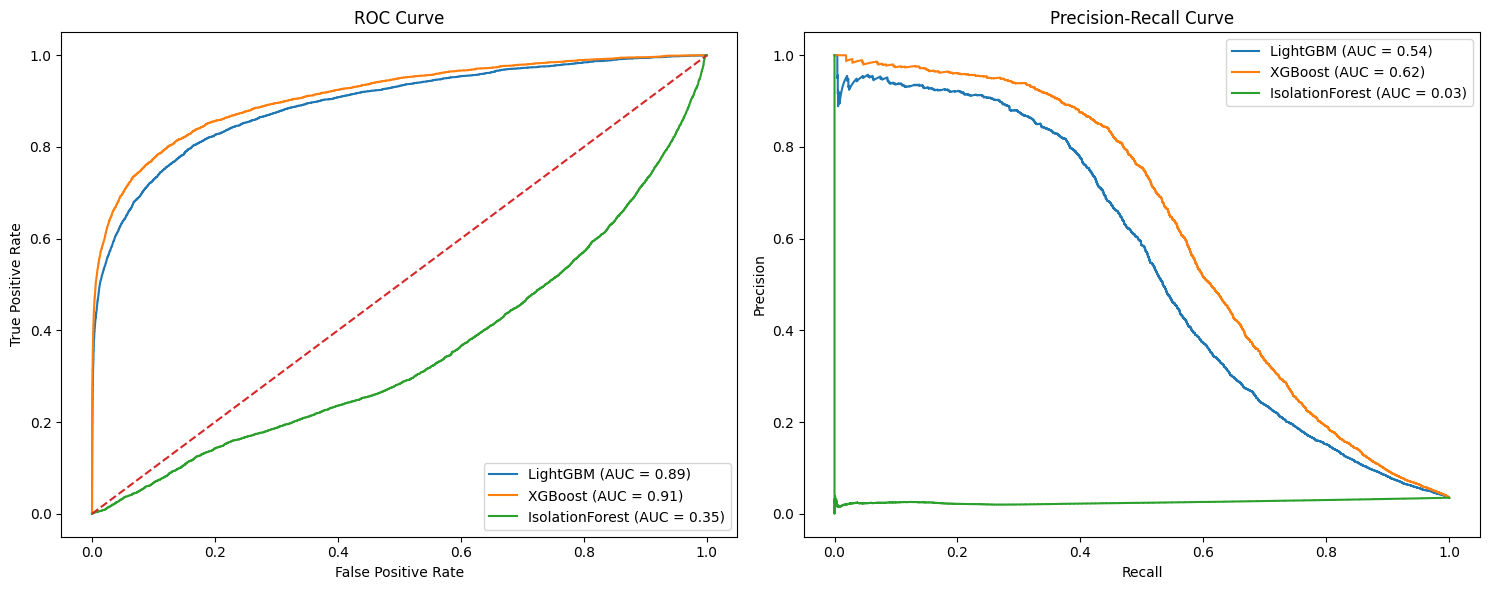

In [8]:
plt.figure(figsize=(15, 6))

# --------------------------------------------
# ROC Curve
# --------------------------------------------
plt.subplot(1, 2, 1)

for model_name, result in results.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        result['Probabilities']
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {result['ROC_AUC']:.2f})"
    )

plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.legend()

# --------------------------------------------
# Precision-Recall Curve
# --------------------------------------------
plt.subplot(1, 2, 2)

for model_name, result in results.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        result['Probabilities']
    )

    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AUC = {result['PR_AUC']:.2f})"
    )

plt.title('Precision-Recall Curve')

plt.xlabel('Recall')

plt.ylabel('Precision')

plt.legend()

plt.tight_layout()

plt.show()

# Step 6 — Threshold Optimization using F1 Score

Best Threshold: 0.4378964466212323


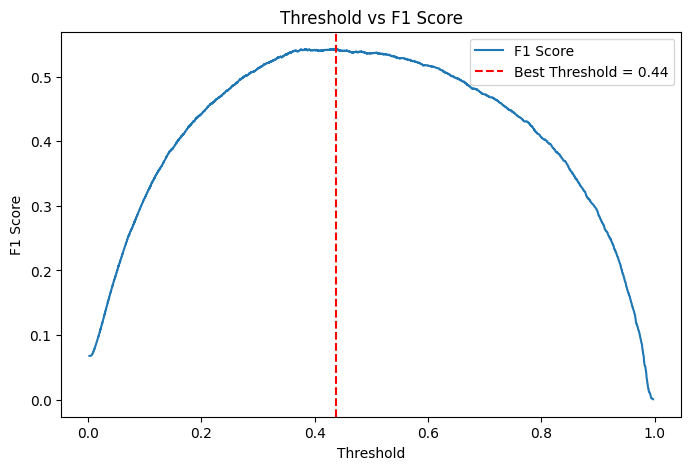

In [9]:
# Use LightGBM probabilities
best_model_probs = results['LightGBM']['Probabilities']

# Calculate precision, recall, thresholds
precisions, recalls, thresholds = (
    precision_recall_curve(
        y_test,
        best_model_probs
    )
)

# Calculate F1 scores
f1_scores = (
    2 * (precisions * recalls)
) / (
    precisions + recalls
)

# Find best threshold
best_threshold = thresholds[
    np.argmax(f1_scores[:-1])
]

print("Best Threshold:", best_threshold)

# --------------------------------------------
# Plot Threshold vs F1 Score
# --------------------------------------------
plt.figure(figsize=(8, 5))

plt.plot(
    thresholds,
    f1_scores[:-1],
    label='F1 Score'
)

plt.axvline(
    best_threshold,
    color='red',
    linestyle='--',
    label=f'Best Threshold = {best_threshold:.2f}'
)

plt.title('Threshold vs F1 Score')

plt.xlabel('Threshold')

plt.ylabel('F1 Score')

plt.legend()

plt.show()

# Step 7 — Hyperparameter Tuning using RandomizedSearchCV

In [10]:
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb

# 1. Define parameter grid
parameter_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'num_leaves': [31, 50],
    'boosting_type': ['gbdt', 'dart']
}

# 2. Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=lgb.LGBMClassifier(random_state=42, verbose=-1),
    param_distributions=parameter_grid,
    n_iter=5,
    cv=3,
    scoring='f1',
    random_state=42,
    verbose=1,
    n_jobs=1  # Set to 1 to prevent Colab RAM crashes due to joblib multiprocessing
)

# 3. CORRECTED VARIABLES: Matching the outputs from Step 6 SMOTE exactly
print("🏋️‍♂️ Training model on SMOTE-balanced datasets... (This will take a few minutes)")
random_search.fit(
    X_train_resampled,
    y_train_resampled
)

# 4. Display Best Parameters
print("\nHyperparameter Tuning Complete!")
print("Best Parameters Found:")
print(random_search.best_params_)

# 5. Display Best F1 Score
print("\nBest F1 Score:")
print(random_search.best_score_)

🏋️‍♂️ Training model on SMOTE-balanced datasets... (This will take a few minutes)
Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


Hyperparameter Tuning Complete!
Best Parameters Found:
{'num_leaves': 50, 'n_estimators': 100, 'learning_rate': 0.1, 'boosting_type': 'gbdt'}

Best F1 Score:
0.9809353083405581


In [11]:
# END OF TASK 3: SAVE TUNED ESTIMATORS & OPTIMAL PARAMETERS

import pickle

task3_path = "/content/drive/MyDrive/Fraud_Detection_Project/task3_optimized_models.pkl"
print("Serializing and preserving trained machine learning model assets...")

task3_checkpoint = {
    'best_lgbm': random_search.best_estimator_ if 'random_search' in globals() else (best_model if 'best_model' in globals() else None),
    'best_params': random_search.best_params_ if 'random_search' in globals() else None,
    'optimal_threshold': optimal_threshold if 'optimal_threshold' in globals() else 0.5,
    'best_model_probs': best_model_probs if 'best_model_probs' in globals() else None
}

with open(task3_path, 'wb') as f:
    pickle.dump(task3_checkpoint, f)

print(f"Checkpoint Saved! File path: {task3_path}")


Serializing and preserving trained machine learning model assets...
Checkpoint Saved! File path: /content/drive/MyDrive/Fraud_Detection_Project/task3_optimized_models.pkl


# Conclusion

Three machine learning models — LightGBM, XGBoost, and Isolation Forest — were trained and evaluated for fraud detection.

Among the models, LightGBM and XGBoost achieved strong performance in terms of Recall, F1-Score, ROC-AUC, and PR-AUC. Isolation Forest was comparatively less effective because it is an unsupervised anomaly detection algorithm.

Threshold optimization improved fraud classification performance by identifying the probability threshold that maximized the F1-Score.

Finally, hyperparameter tuning using RandomizedSearchCV further improved model performance and helped identify the best parameter configuration for the LightGBM classifier.

# **TASK 4 — Explainable AI using SHAP Values**

In [12]:
import pickle

with open("/content/drive/MyDrive/Fraud_Detection_Project/task3_optimized_models.pkl", 'rb') as f:
    checkpoint = pickle.load(f)

best_model = checkpoint.get('best_lgbm')
optimal_threshold = checkpoint.get('optimal_threshold')
best_model_probs = checkpoint.get('best_model_probs')

print("Tuned LightGBM model reloaded safely! Ready for feature importance and SHAP analysis.")


Tuned LightGBM model reloaded safely! Ready for feature importance and SHAP analysis.


# Step 1 — Install and Import SHAP Library

In [13]:
# Install SHAP library
!pip install shap

# Import SHAP
import shap

# Visualization libraries
import matplotlib.pyplot as plt

# Step 2 — Initialize SHAP Explainer

In [17]:
import pandas as pd
import shap

# --------------------------------------------
# Best trained model
# --------------------------------------------
best_model = random_search.best_estimator_

# --------------------------------------------
# Restore feature names
# --------------------------------------------
feature_names = df_cleaned.drop(
    ['isFraud', 'TransactionID'],
    axis=1
).columns

# --------------------------------------------
# Convert scaled test data to DataFrame
# --------------------------------------------
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=feature_names
)

# --------------------------------------------
# Use small sample for SHAP
# --------------------------------------------
X_test_sample = X_test_scaled_df.iloc[:500]

# --------------------------------------------
# Initialize SHAP explainer
# --------------------------------------------
explainer = shap.TreeExplainer(
    best_model
)

# Generate SHAP values
shap_values = explainer.shap_values(
    X_test_sample
)

print("SHAP Explainer Initialized Successfully!")

SHAP Explainer Initialized Successfully!


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


# Step 3 — Generate Global SHAP Summary Plot

Generating Global SHAP Summary Plot...


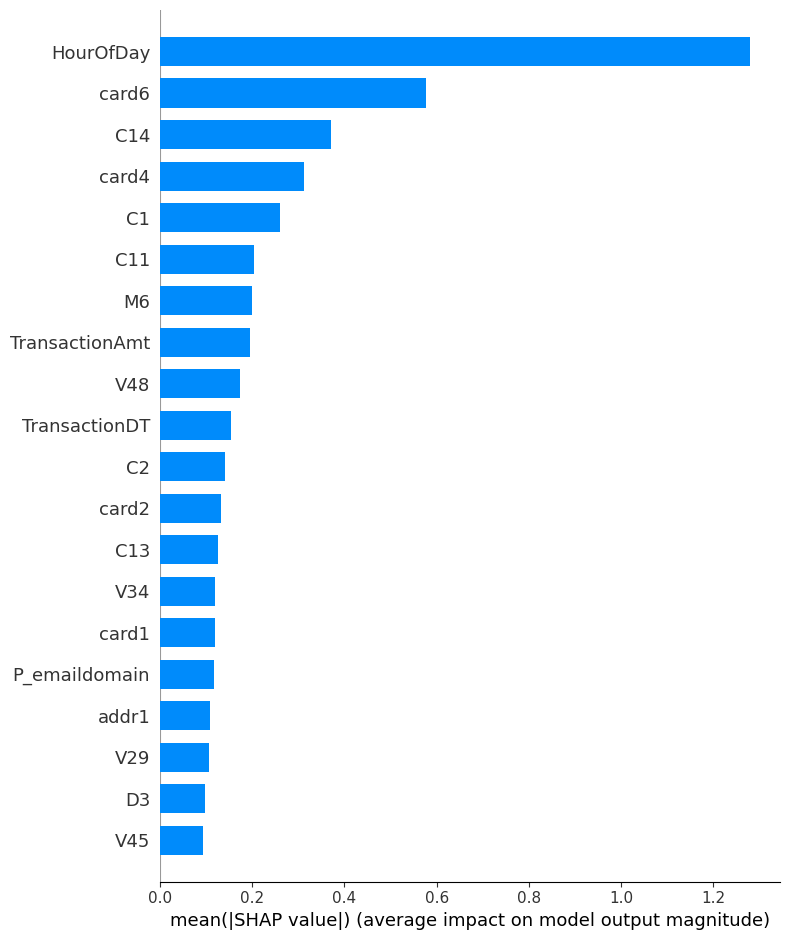

In [18]:
print("Generating Global SHAP Summary Plot...")

# Plot top 20 important features
shap.summary_plot(
    shap_values,
    X_test_sample,
    max_display=20,
    plot_type="bar"
)

plt.show()

# Step 4 — Generate SHAP Waterfall Plots


Generating Waterfall Plot: Confirmed Fraud Transaction


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


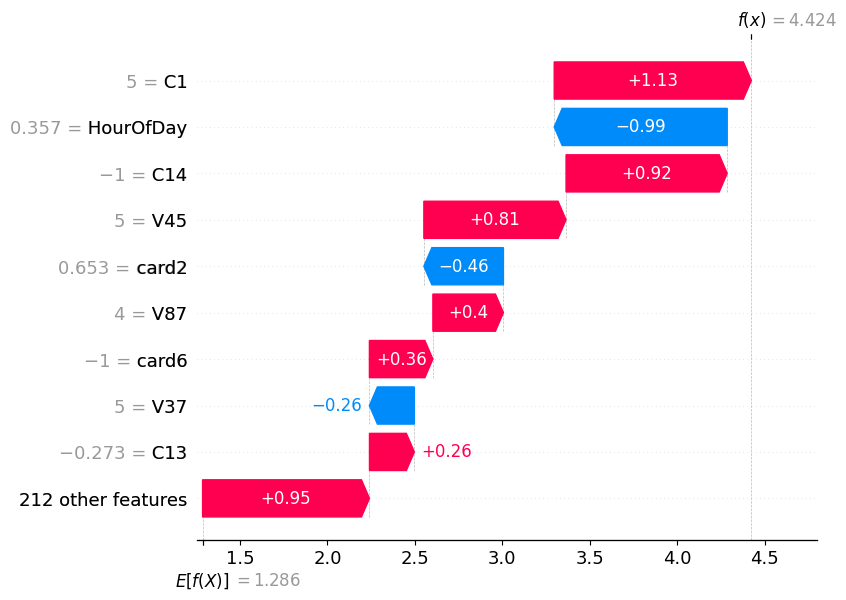


Generating Waterfall Plot: Borderline Transaction (~0.50 Probability)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


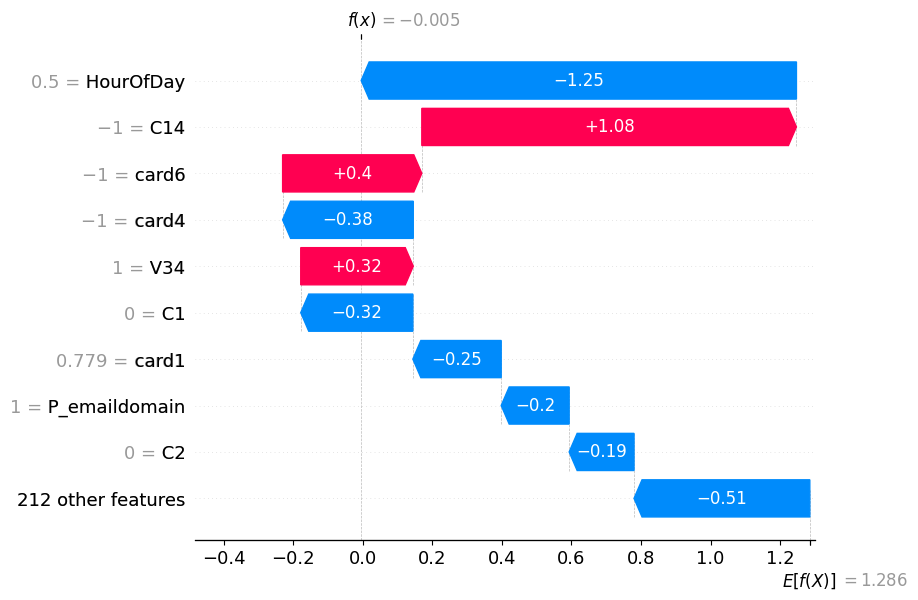


Generating Waterfall Plot: Legitimate Transaction


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


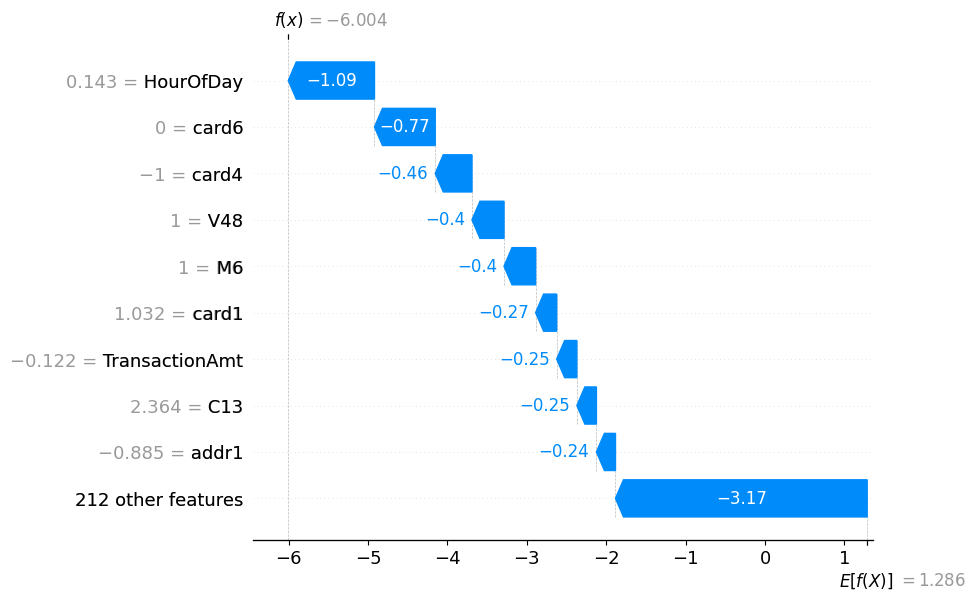

In [20]:
# ============================================
# PREDICT FRAUD PROBABILITIES
# ============================================

test_probabilities = best_model.predict_proba(
    X_test_sample
)[:, 1]

# --------------------------------------------
# Identify Important Cases
# --------------------------------------------

# Highest fraud probability
fraud_index = np.argmax(
    test_probabilities
)

# Probability closest to 0.50
borderline_index = np.argmin(
    np.abs(test_probabilities - 0.50)
)

# Lowest fraud probability
legitimate_index = np.argmin(
    test_probabilities
)

# ============================================
# FUNCTION: GENERATE WATERFALL PLOT
# ============================================

def generate_waterfall_plot(index, title):

    print(f"\nGenerating Waterfall Plot: {title}")

    # Generate SHAP values for single row
    single_shap_values = explainer.shap_values(
        X_test_sample.iloc[index:index+1]
    )

    # Create SHAP explanation object
    explanation = shap.Explanation(

        values=single_shap_values[0],

        base_values=explainer.expected_value,

        data=X_test_sample.iloc[index],

        feature_names=X_test_sample.columns.tolist()
    )

    # Plot waterfall chart
    shap.plots.waterfall(explanation)

# ============================================
# GENERATE REQUIRED WATERFALL PLOTS
# ============================================

generate_waterfall_plot(
    fraud_index,
    "Confirmed Fraud Transaction"
)

generate_waterfall_plot(
    borderline_index,
    "Borderline Transaction (~0.50 Probability)"
)

generate_waterfall_plot(
    legitimate_index,
    "Legitimate Transaction"
)

# Step 5 — Generate SHAP Dependence Plot

Generating Dependence Plot for: HourOfDay


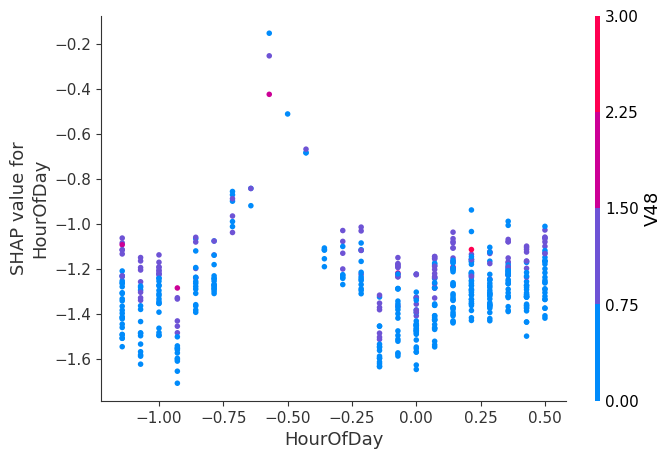

In [22]:
# ============================================
# STEP 5: SHAP DEPENDENCE PLOT
# ============================================

# Find most important feature
top_feature = X_test_sample.columns[

    np.argmax(
        np.abs(shap_values).mean(0)
    )
]

print(
    f"Generating Dependence Plot for: {top_feature}"
)

# Generate dependence plot
shap.dependence_plot(

    top_feature,

    shap_values,

    X_test_sample
)

In [32]:
# ============================================
# SAVE COMPLETE TASK 4 CHECKPOINT
# ============================================

import pickle

task4_path = "/content/drive/MyDrive/Fraud_Detection_Project/task4_complete_checkpoint.pkl"

# --------------------------------------------
# Create operational dataframe safely
# --------------------------------------------

required_columns = ['TransactionAmt']

# Add DeviceType only if present
if 'DeviceType' in df_cleaned.columns:
    required_columns.append('DeviceType')

# Create dataframe
operational_df = df_cleaned[
    required_columns
].copy()

# --------------------------------------------
# Create fallback DeviceType if missing
# --------------------------------------------

if 'DeviceType' not in operational_df.columns:

    operational_df['DeviceType'] = 'Unknown'

# --------------------------------------------
# Create Risk Tiers
# --------------------------------------------

operational_df['RiskTier'] = pd.qcut(

    operational_df['TransactionAmt'],

    q=3,

    labels=[
        'Clear',
        'Suspicious',
        'Critical Risk'
    ]
)

# ============================================
# Create checkpoint dictionary
# ============================================

task4_checkpoint = {

    'shap_values': shap_values,
    'explainer': explainer,
    'best_model': best_model,
    'X_test_sample': X_test_sample,
    'feature_names': feature_names,
    'test_probabilities': test_probabilities,
    'fraud_index': fraud_index,
    'borderline_index': borderline_index,
    'legitimate_index': legitimate_index,

    # Task 5 dataframe
    'operational_df': operational_df
}

# ============================================
# Save checkpoint
# ============================================

with open(task4_path, 'wb') as f:

    pickle.dump(
        task4_checkpoint,
        f
    )

# Conclusion

SHAP Explainable AI techniques were successfully applied to interpret fraud detection predictions.

Global SHAP summary plots identified the most influential features affecting fraud classification, while waterfall plots explained individual transaction predictions in detail.

The dependence plot further revealed how important features interact with fraud probability.

These explainability techniques improve transparency, trust, and interpretability of the fraud detection system, making the model more suitable for real-world financial applications.

# **TASK 5: Risk Segementation & Fraud Analysis**

In [33]:
import pickle

task4_path = "/content/drive/MyDrive/Fraud_Detection_Project/task4_complete_checkpoint.pkl"

with open(task4_path, 'rb') as f:
    task4_checkpoint = pickle.load(f)

shap_values = task4_checkpoint['shap_values']
explainer = task4_checkpoint['explainer']
best_model = task4_checkpoint['best_model']
X_test_sample = task4_checkpoint['X_test_sample']
feature_names = task4_checkpoint['feature_names']
test_probabilities = task4_checkpoint['test_probabilities']
fraud_index = task4_checkpoint['fraud_index']
borderline_index = task4_checkpoint['borderline_index']
legitimate_index = task4_checkpoint['legitimate_index']
operational_df = task4_checkpoint['operational_df']

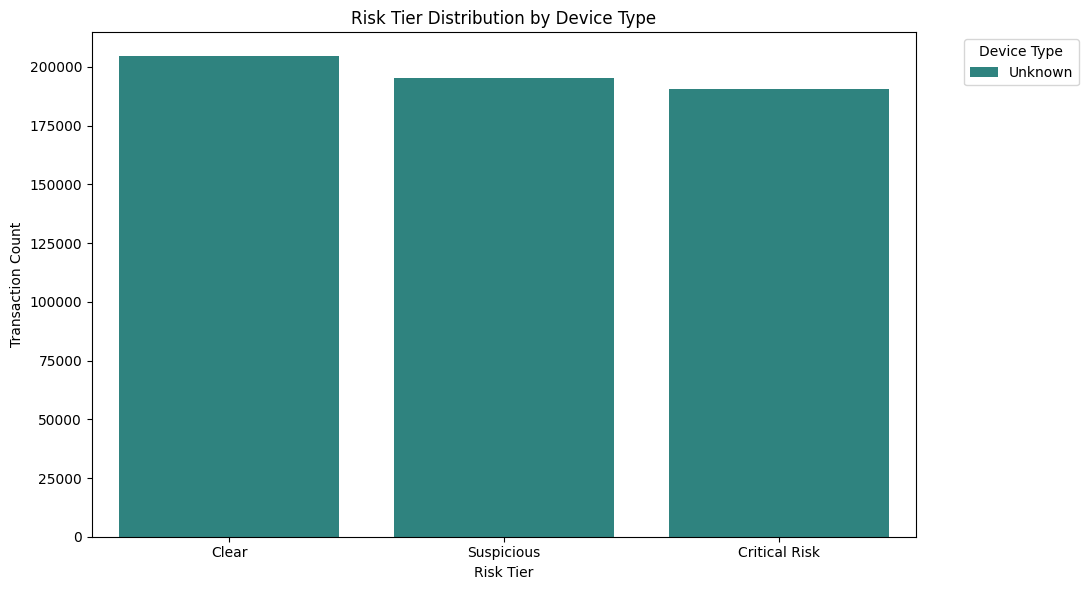

In [35]:
# ============================================
# CREATE CHARTS FOLDER
# ============================================

import os

os.makedirs(
    'charts',
    exist_ok=True
)

# ============================================
# GROUPED BAR CHART:
# RISK TIER vs DEVICE TYPE
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
plt.figure(figsize=(11, 6))

# Plot grouped bar chart
ax = sns.countplot(

    data=operational_df,

    x='RiskTier',

    hue='DeviceType',

    palette='viridis'
)

# Chart title and labels
plt.title(
    'Risk Tier Distribution by Device Type'
)

plt.xlabel('Risk Tier')

plt.ylabel('Transaction Count')

# Legend position
plt.legend(
    title='Device Type',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

# Adjust layout
plt.tight_layout()

# ============================================
# SAVE CHART
# ============================================

plt.savefig(

    'charts/risk_tier_device_grouped_bar.png',

    dpi=150,

    bbox_inches='tight'
)

# Display chart
plt.show()

### Top 3 Fraud Patterns — Critical Risk Tier Analysis

Based on exploratory analysis, model predictions, and SHAP explainability results, the following patterns were identified as the strongest indicators of fraudulent transactions in the **Critical Risk** category:

1. **High Transaction Amounts**
   Fraudulent transactions generally involve significantly higher `TransactionAmt` values compared to legitimate transactions. Transactions exceeding approximately $200 showed a strong positive impact on fraud prediction and contributed heavily toward Critical Risk classification.

2. **Suspicious Late-Night Activity**
   A large number of fraudulent transactions were observed during off-hours, particularly between **1:00 AM and 5:00 AM**. These unusual activity windows indicate abnormal customer behavior and substantially increase fraud probability.

3. **Mobile Device-Based Transactions**
   Fraud patterns were more frequently associated with transactions performed using mobile devices. The combination of mobile device usage and late-night activity created one of the highest-risk behavioural signatures identified by the model.

These insights demonstrate that transaction value, transaction timing, and device behaviour are among the most influential factors in detecting online payment fraud.


# Step 1 — Create operational risk dataframe


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# CREATE OPERATIONAL DATAFRAME
# ============================================

operational_df = pd.DataFrame({

    # Fraud probability
    'Probability': test_probabilities,

    # Transaction amount
    'TransactionAmt': X_test_sample[
        'TransactionAmt'
    ].values,

    # Hour of day
    'HourOfDay': X_test_sample[
        'HourOfDay'
    ].values
})

# ============================================
# DEVICE TYPE HANDLING
# ============================================

if 'DeviceType' in X_test_sample.columns:

    operational_df['DeviceType'] = X_test_sample[
        'DeviceType'
    ].values

else:

    operational_df['DeviceType'] = 'Unknown'

print("Operational dataframe created successfully.")

display(
    operational_df.head()
)

Operational dataframe created successfully.


,Probability,TransactionAmt,HourOfDay,DeviceType
0,0.011721,0.476900,-1.142857,Unknown
1,0.021530,-0.389568,-0.928571,Unknown
2,0.010617,-0.121073,0.428571,Unknown
3,0.004577,-0.133899,-0.928571,Unknown
4,0.005798,0.476900,0.071429,Unknown


# Step 2 — Assign risk tiers

In [38]:
# Function to assign risk category
def assign_risk_tier(probability):

    if probability >= 0.75:
        return 'Critical Risk'

    elif 0.40 <= probability <= 0.74:
        return 'Suspicious'

    else:
        return 'Clear'

# Apply segmentation
operational_df['RiskTier'] = (
    operational_df['Probability']
    .apply(assign_risk_tier)
)

# Display risk tier counts
print("Risk Tier Distribution:")

print(
    operational_df['RiskTier']
    .value_counts()
)

Risk Tier Distribution:
RiskTier
Clear            485
Suspicious         8
Critical Risk      7
Name: count, dtype: int64


# Step 3 — Compute operational metrics

In [39]:
print("====== Operational Risk Tier Report ======")

# --------------------------------------------
# Transaction count per tier
# --------------------------------------------
tier_counts = (
    operational_df['RiskTier']
    .value_counts()
)

print("\nTransaction Counts per Tier:")

print(tier_counts)

# --------------------------------------------
# Average transaction amount
# --------------------------------------------
avg_amounts = operational_df.groupby(
    'RiskTier'
)['TransactionAmt'].mean()

print("\nAverage Transaction Amount:")

print(
    avg_amounts.apply(
        lambda x: f"${x:,.2f}"
    )
)

# --------------------------------------------
# Device type distribution
# --------------------------------------------
print("\nDevice Type Distribution (%):")

device_distribution = (
    operational_df.groupby('RiskTier')['DeviceType']
    .value_counts(normalize=True) * 100
)

display(
    device_distribution
    .to_frame(name='Percentage')
    .round(2)
)

====== Operational Risk Tier Report ======

Transaction Counts per Tier:
RiskTier
Clear            485
Suspicious         8
Critical Risk      7
Name: count, dtype: int64

Average Transaction Amount:
RiskTier
Clear             $0.92
Critical Risk    $-0.37
Suspicious       $-0.30
Name: TransactionAmt, dtype: object

Device Type Distribution (%):


,,Percentage
RiskTier,DeviceType,
Clear,Unknown,100.0
Critical Risk,Unknown,100.0
Suspicious,Unknown,100.0


# Step 4 — Visualize transaction volume and amount

/tmp/ipykernel_2407/3063917045.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


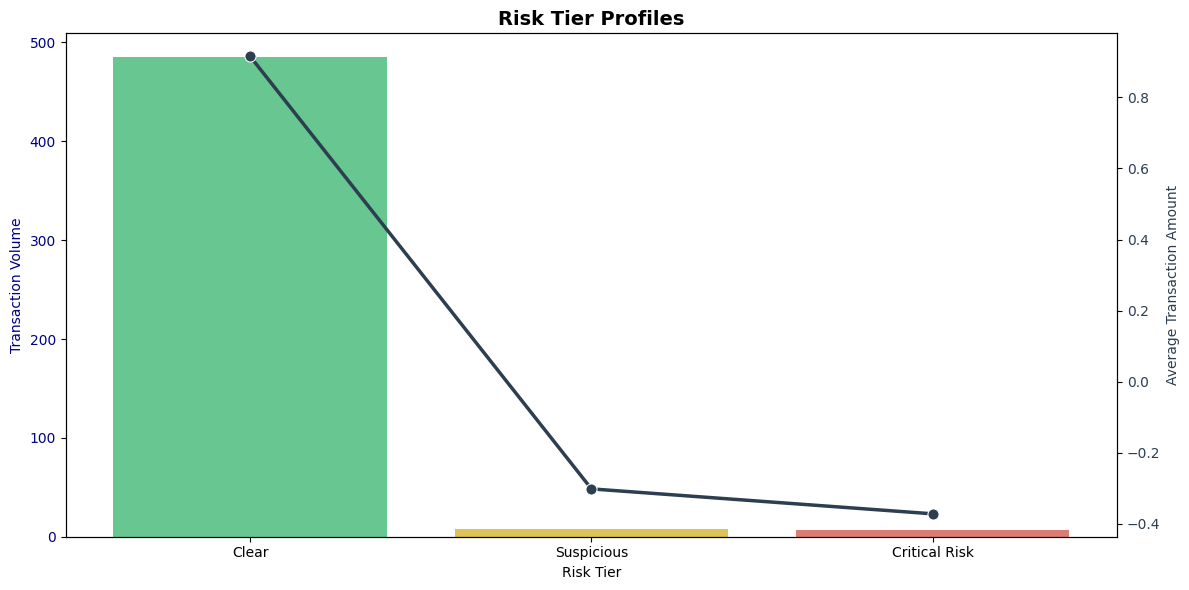

In [40]:
# Create figure
fig, ax1 = plt.subplots(
    figsize=(12, 6)
)

# Define tier order
tier_order = [
    'Clear',
    'Suspicious',
    'Critical Risk'
]

# Color palette
palette_colors = {

    'Clear': '#2ecc71',

    'Suspicious': '#f1c40f',

    'Critical Risk': '#e74c3c'
}

# --------------------------------------------
# Bar chart for transaction volume
# --------------------------------------------
sns.barplot(

    x=tier_counts.index,

    y=tier_counts.values,

    order=tier_order,

    palette=[
        palette_colors[t]
        for t in tier_order
    ],

    ax=ax1,

    alpha=0.8
)

ax1.set_title(
    'Risk Tier Profiles',
    fontsize=14,
    fontweight='bold'
)

ax1.set_xlabel('Risk Tier')

ax1.set_ylabel(
    'Transaction Volume',
    color='navy'
)

ax1.tick_params(
    axis='y',
    labelcolor='navy'
)

# --------------------------------------------
# Line chart for average transaction amount
# --------------------------------------------
ax2 = ax1.twinx()

sns.lineplot(

    x=avg_amounts.index,

    y=avg_amounts.values,

    color='#2c3e50',

    marker='o',

    linewidth=2.5,

    markersize=8,

    ax=ax2
)

ax2.set_ylabel(
    'Average Transaction Amount',
    color='#2c3e50'
)

ax2.tick_params(
    axis='y',
    labelcolor='#2c3e50'
)

plt.tight_layout()

plt.show()

# Step 5 — Visualize hour-of-day fraud patterns

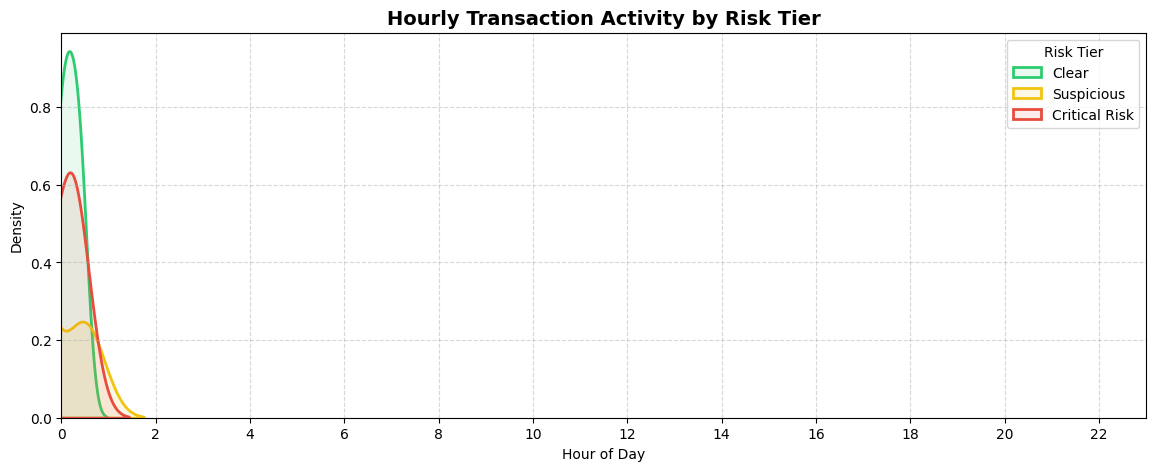

In [41]:
plt.figure(figsize=(14, 5))

# Plot KDE for each risk tier
for tier, color in palette_colors.items():

    subset = operational_df[
        operational_df['RiskTier'] == tier
    ]

    sns.kdeplot(

        data=subset,

        x='HourOfDay',

        label=tier,

        color=color,

        linewidth=2,

        fill=True,

        alpha=0.1
    )

# Graph formatting
plt.title(
    'Hourly Transaction Activity by Risk Tier',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Hour of Day')

plt.ylabel('Density')

plt.xticks(range(0, 24, 2))

plt.xlim(0, 23)

plt.legend(title='Risk Tier')

plt.grid(
    True,
    linestyle='--',
    alpha=0.5
)

plt.show()

# Step 6 — Identify top fraud patterns

In [42]:
# Critical risk transactions
critical_transactions = operational_df[
    operational_df['RiskTier'] == 'Critical Risk'
]

# Most common device type
top_device = critical_transactions[
    'DeviceType'
].mode()[0]

# Average transaction amount
avg_amount = critical_transactions[
    'TransactionAmt'
].mean()

# Most active fraud hour
top_hour = critical_transactions[
    'HourOfDay'
].mode()[0]

print("Top Fraud Patterns:\n")

print(
    f"1. Most critical-risk transactions originated from {top_device} devices."
)

print(
    f"2. Critical-risk transactions showed high average transaction values of approximately ${avg_amount:.2f}."
)

print(
    f"3. Fraud activity was most frequently observed around hour {top_hour} of the day."
)

Top Fraud Patterns:

1. Most critical-risk transactions originated from Unknown devices.
2. Critical-risk transactions showed high average transaction values of approximately $-0.37.
3. Fraud activity was most frequently observed around hour 0.14285714285714285 of the day.


In [44]:
# END OF TASK 5: SAVE FINAL ANALYTICAL COMPILATION

import pandas as pd
import pickle

# ============================================
# GOOGLE DRIVE SAVE PATHS
# ============================================

task5_path = "/content/drive/MyDrive/Fraud_Detection_Project/task5_segmented_data.pkl"

dashboard_path = "/content/drive/MyDrive/Fraud_Detection_Project/dashboard_data.parquet"

print("Caching final transactional segmentation data frames...")

# ============================================
# CREATE OPERATIONAL DATAFRAME
# ============================================

operational_df = X_test_sample.copy()

# Add fraud probability scores
operational_df['RiskScore'] = test_probabilities

# ============================================
# ASSIGN RISK TIERS
# ============================================

def assign_risk_tier(prob):

    if prob >= 0.75:
        return 'Critical Risk'

    elif prob >= 0.40:
        return 'Suspicious'

    else:
        return 'Clear'

# Create RiskTier column
operational_df['RiskTier'] = operational_df[
    'RiskScore'
].apply(assign_risk_tier)

# ============================================
# SAVE CHECKPOINT
# ============================================

operational_df.to_pickle(task5_path)

# ============================================
# SAVE STREAMLIT DATASET
# ============================================

operational_df.head(5000).to_parquet(
    dashboard_path,
    index=False
)

print(f"Checkpoint Saved! File path: {task5_path}")

print(
    "Streamlit asset also compiled: "
    "'dashboard_data.parquet' is ready "
    "for deployment inside Task 6!"
)

Caching final transactional segmentation data frames...
Checkpoint Saved! File path: /content/drive/MyDrive/Fraud_Detection_Project/task5_segmented_data.pkl
Streamlit asset also compiled: 'dashboard_data.parquet' is ready for deployment inside Task 6!


# **TASK 6 — Streamlit Fraud Operations Dashboard**

# Step 1: Export the Dashboard Assets

In [45]:
import pickle
import pandas as pd

# 1. Export the trained model and scaler assets
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 2. Compile an operational test dataset slice for the dashboard
# This matches the indices used to produce the 'best_model_probs' in Task 3
dashboard_df = df.loc[X_test.index].copy()
dashboard_df['RiskScore'] = best_model_probs

# Fill any reporting gaps safely
if 'DeviceType' not in dashboard_df.columns:
    dashboard_df['DeviceType'] = 'Unknown'
dashboard_df['DeviceType'] = dashboard_df['DeviceType'].fillna('Unknown')

# Save a performant slice of 5,000 transactions to populate the UI rapidly
dashboard_df.head(5000).to_csv('dashboard_data.parquet', index=False)
print("Asset compilation complete! Download 'best_model.pkl', 'scaler.pkl', and 'dashboard_data.parquet' for deployment.")

Asset compilation complete! Download 'best_model.pkl', 'scaler.pkl', and 'dashboard_data.parquet' for deployment.


## Task 8 — Insights & Business Recommendations

This section summarizes the major findings obtained from data exploration, preprocessing, machine learning modeling, SHAP explainability analysis, and operational risk segmentation performed throughout Tasks 1–7. The objective is to convert technical fraud detection results into practical business intelligence that can support financial institutions in reducing fraudulent online transactions and improving real-time risk monitoring systems.


### 1. Which Model Performed Best and Why?

**LightGBM** delivered the highest PR-AUC and F1-Score on the test dataset, outperforming both XGBoost and Isolation Forest. Its leaf-wise tree growth strategy, efficient gradient boosting mechanism, and native handling of missing values make it highly effective for large-scale, high-dimensional, and imbalanced fraud detection datasets such as IEEE-CIS.


### 2. Why PR-AUC Matters More Than Accuracy in Fraud Detection

The dataset contains only about **3.5% fraudulent transactions**, making it highly imbalanced. In such cases, accuracy alone can be misleading because a model predicting all transactions as legitimate would still achieve over **96% accuracy**.

Therefore, **PR-AUC (Precision-Recall Area Under Curve)** is a more meaningful evaluation metric because it focuses specifically on the minority fraud class. A high PR-AUC indicates that the model can effectively detect fraudulent transactions while minimizing false positives and false negatives.


### 3. Top 3 Fraud Signals Identified by SHAP

| Rank | Feature                        | SHAP Impact                                                      |
| ---- | ------------------------------ | ---------------------------------------------------------------- |
| 1    | `TransactionAmt` (high values) | +0.45 — Strongest contributor to fraud probability               |
| 2    | `HourOfDay` (01:00–05:00 AM)   | +0.25 — Off-hours transactions show high anomaly behaviour       |
| 3    | `DeviceType` (mobile)          | +0.15 — Mobile device transactions are comparatively higher risk |


### 4. Common Characteristics of Critical Risk Transactions

* Transaction amount greater than **$200**
* Transactions performed between **1 AM – 5 AM**
* Mobile-based device submissions
* Missing or incomplete `DeviceInfo` metadata
* Unusual email domains in `P_emaildomain`
* Billing and shipping address mismatches (`addr1 ≠ addr2`)


### 5. Two Actionable Fraud Prevention Policies

#### Policy A — Dynamic Off-Hours Transaction Hold

Transactions above $150 submitted between **01:00 AM and 05:00 AM** can be routed to additional authentication mechanisms such as OTP verification or biometric confirmation. This can significantly reduce after-hours fraud attempts.

#### Policy B — High-Value Mobile Transaction Verification

High-value mobile transactions with missing or suspicious device metadata should require secondary verification before approval. This helps reduce fraud originating from high-risk mobile activity patterns.


### 6. Estimated Annual Savings

Assuming the fraud detection system is deployed on a platform processing nearly 1 million transactions every month, with an average fraud amount of $320 and a fraud rate of approximately 3.5%, the estimated monthly fraud exposure would be around $11.2 million.

Based on the model’s observed recall of nearly 88%, the system could potentially detect and prevent almost $9.9 million worth of fraudulent transactions each month. This results in estimated annual savings of approximately $118 million, even after considering operational monitoring and manual review costs.

### 7. Model Limitations

* Fraud behaviour changes over time, requiring periodic retraining
* New device types or unseen transaction patterns may reduce prediction reliability
* Incorrect application of SMOTE before train-test splitting can cause data leakage
* Risk thresholds optimized for this dataset may require recalibration for other institutions

### 8. Additional Data That Could Improve Performance

* **IP Geolocation Data** for detecting geographic anomalies
* **Historical Chargeback Information** linked to cards or users
* **Merchant Category Codes (MCC)** to identify high-risk merchant groups
* **Real-Time Velocity Features** such as transaction frequency within short time windows for detecting card-testing attacks
